In [5]:
"""
Transform AVP-BDD REDCap export into Cleaned_Demographics format,
compute summary scores (QIDS, STAI state/trait, BDD symptom & severity),
and produce a between-group comparison table (t-tests + chi-square).
"""

import os
import pandas as pd
import numpy as np
from scipy import stats

# ---------------------------------------------------------------------------
# 1. Load raw REDCap export
#    Auto-detect the header row so this works whether the column names are
#    on row 0 (standard CSV-like export) or row 1 (REDCap export with a
#    metadata/filename banner on the first row).
# ---------------------------------------------------------------------------
INPUT_PATH   = "/Volumes/drive/AVP-BDD/AVP-BDD_redcap.xlsx"
OUTPUT_PATH  = "/Volumes/drive/AVP-BDD/Cleaned_Demographics.xlsx"
SUMMARY_PATH = os.path.join(os.path.dirname(OUTPUT_PATH),
                            "Group_Comparison_Summary.xlsx")

def load_redcap(path, anchor_cols=('record_id', 'redcap_survey_identifier',
                                   'qidssr_mood', 'stai1', 'demo_age')):
    """Scan the first few rows to find the real header, then re-read."""
    raw = pd.read_excel(path, sheet_name=0, header=None,
                        nrows=5, engine='openpyxl')
    for i in range(len(raw)):
        row_values = set(str(v).strip() for v in raw.iloc[i].tolist())
        if any(col in row_values for col in anchor_cols):
            return pd.read_excel(path, sheet_name=0, header=i,
                                 engine='openpyxl').copy()
    raise ValueError(
        f"Could not find a header row in {path}. "
        f"Expected one of {anchor_cols} in the first 5 rows."
    )

df = load_redcap(INPUT_PATH)

# --- Sanity check: make sure critical columns actually exist ----------------
required = ['redcap_survey_identifier', 'demo_age', 'demo_sex_at_birth',
            'qidssr_mood', 'stai1', 'bdd_ss1']
missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise KeyError(
        f"Expected columns not found in the file: {missing_required}\n"
        f"First 20 columns actually in the file: {df.columns.tolist()[:20]}"
    )

# Flag subjects missing core demographics (informational, not fatal)
for col in ['redcap_survey_identifier', 'demo_age', 'demo_sex_at_birth']:
    missing = df[df[col].isna()]['redcap_survey_identifier'].tolist()
    if missing:
        print(f"WARNING: Missing {col} for subjects: {missing}")

# Drop rows without a subject ID (stray incomplete records)
df = df[df['redcap_survey_identifier'].notna()].copy()

# ---------------------------------------------------------------------------
# 2. Compute summary scores from item-level data
#    `min_count=1` means: if ALL items are missing, the sum is NaN (not 0).
# ---------------------------------------------------------------------------

# --- QIDS total ---
qids_items = [
    'qidssr_sleep_onset', 'qidssr_sleep_noct', 'qidssr_sleep_morn',
    'qidssr_sleep_hyper', 'qidssr_mood', 'qidssr_app_dec', 'qidssr_app_inc',
    'qidssr_weight_dec', 'qidssr_weight_inc', 'qidssr_conc', 'qidssr_outlook',
    'qidssr_suicide', 'qidssr_involve', 'qidssr_energy',
    'qidssr_motor_slow', 'qidssr_motor_agit',
]
df['qids_total'] = df[qids_items].sum(axis=1, min_count=1)

# --- STAI State (items 1-20): reverse-code some items, then sum ---
stai_state_direct  = ['stai3','stai4','stai6','stai7','stai9','stai10',
                      'stai12','stai13','stai14','stai17','stai18']
stai_state_reverse = ['stai1','stai2','stai5','stai8','stai11',
                      'stai15','stai16','stai19','stai20']

state = df[stai_state_direct + stai_state_reverse].copy()
state[stai_state_reverse] = 5 - state[stai_state_reverse]
df['stai_state'] = state.sum(axis=1, min_count=1)

# --- STAI Trait (items 21-40) ---
stai_trait_direct  = ['stai22','stai24','stai25','stai28','stai29',
                      'stai31','stai32','stai35','stai37','stai38','stai40']
stai_trait_reverse = ['stai21','stai23','stai26','stai27','stai30',
                      'stai33','stai34','stai36','stai39']

trait = df[stai_trait_direct + stai_trait_reverse].copy()
trait[stai_trait_reverse] = 5 - trait[stai_trait_reverse]
df['stai_trait'] = trait.sum(axis=1, min_count=1)

# --- BDD Symptom Scale: split between symptom items (bdd_ss#) and rater items ---
bdd_symptom_cols  = [c for c in df.columns
                     if c.startswith('bdd_ss')
                     and '_rater' not in c
                     and c not in ('bdd_symptom_scale_timestamp',
                                   'bdd_symptom_scale_complete')]
bdd_severity_cols = [c for c in df.columns if c.startswith('bdd_ss_rater')]

df['bdd_ss_symptom']  = df[bdd_symptom_cols].sum(axis=1, min_count=1)
df['bdd_ss_severity'] = df[bdd_severity_cols].sum(axis=1, min_count=1)

# ---------------------------------------------------------------------------
# 3. Decode REDCap checkbox columns (demo_gender___N, demo_race..., demo_edu...)
#    into single-valued numeric columns + human-readable labels.
#
#    When a subject has >1 box checked (multi-racial, conflicting edu),
#    take the LOWEST code selected (matches the original cleaned file).
# ---------------------------------------------------------------------------

def first_checked(row, prefix, codes):
    """Return the smallest code N for which demo_{prefix}___N == 1, else NaN."""
    for code in codes:
        col = f"{prefix}___{code}"
        if col in row.index and row[col] == 1:
            return code
    return np.nan

gender_labels = {
    1: 'cis female',
    2: 'cis male',
    3: 'trans female',
    4: 'trans male',
    5: 'other (non-binary, genderqueer, etc.)',
    0: 'prefer not to say',
}
df['gender'] = df.apply(
    lambda r: first_checked(r, 'demo_gender', [1, 2, 3, 4, 5, 0]), axis=1
)

race_labels = {
    1: 'Native American',
    2: 'Asian',
    3: 'Black/African American',
    4: 'Hispanic/Latinx',
    5: 'Middle Eastern/North African',
    6: 'Native Hawaiian/Pacific Islander',
    7: 'White',
    8: 'Other',
    0: 'prefer not to say',
}
df['race'] = df.apply(
    lambda r: first_checked(r, 'demo_race_and_ethnicity',
                            [1, 2, 3, 4, 5, 6, 7, 8, 0]),
    axis=1,
)

edu_labels = {
    1: 'less than high school',
    2: 'high school or GED',
    3: 'some college',
    4: 'associates degree',
    5: 'bachelors degree',
    6: 'some graduate school',
    7: 'masters degree',
    8: 'doctoral degree',
    0: 'prefer not to say',
}
df['education'] = df.apply(
    lambda r: first_checked(r, 'demo_highest_edu',
                            [1, 2, 3, 4, 5, 6, 7, 8, 0]),
    axis=1,
)

sex_labels = {1: 'female', 2: 'male'}

# ---------------------------------------------------------------------------
# 4. Assemble cleaned dataframe
#    Use nullable 'Int64' throughout so NaN values don't blow up the cast.
# ---------------------------------------------------------------------------
clean = pd.DataFrame({
    'sID':             df['redcap_survey_identifier'].astype('Int64'),
    'age':             df['demo_age'].astype('Int64'),
    'sex':             df['demo_sex_at_birth'].astype('Int64'),
    'sex-label':       df['demo_sex_at_birth'].map(sex_labels),
    'gender':          df['gender'].astype('Int64'),
    'gender-label':    df['gender'].map(gender_labels),
    'race':            df['race'].astype('Int64'),
    'race-label':      df['race'].map(race_labels),
    'education':       df['education'],
    'edu-label':       df['education'].map(edu_labels),
    'qids_total':      df['qids_total'].astype('Int64'),
    'stai_state':      df['stai_state'].astype('Int64'),
    'stai_trait':      df['stai_trait'].astype('Int64'),
    'bdd_ss_symptom':  df['bdd_ss_symptom'].astype('Int64'),
    'bdd_ss_severity': df['bdd_ss_severity'].astype('Int64'),
})

# Group: sID starting with 1 = Patients, 2 = Controls
clean['group'] = np.where(clean['sID'] // 100 == 1, 'Patients', 'Controls')

# Order: Patients first, then Controls; within each, sort by sID
clean = clean.sort_values(
    by=['group', 'sID'],
    key=lambda c: c.map({'Patients': 0, 'Controls': 1}) if c.name == 'group' else c,
).reset_index(drop=True)

# ---------------------------------------------------------------------------
# 5. Save cleaned demographics file
# ---------------------------------------------------------------------------
clean.to_excel(OUTPUT_PATH, index=False)
print(f"Cleaned file saved to: {OUTPUT_PATH}")
print(f"Shape: {clean.shape}")
print(clean.head())

# ---------------------------------------------------------------------------
# 6. Between-group statistical comparison
#    - Numerical: Welch's t-test (does not assume equal variance)
#    - Categorical: chi-square test of independence
# ---------------------------------------------------------------------------
numerical_vars = [
    'age', 'qids_total', 'stai_state', 'stai_trait',
    'bdd_ss_symptom', 'bdd_ss_severity',
]
categorical_vars = {
    'sex':       'sex-label',
    'gender':    'gender-label',
    'race':      'race-label',
    'education': 'edu-label',
}

patients = clean[clean['group'] == 'Patients']
controls = clean[clean['group'] == 'Controls']

rows = []

# --- Numerical ---
for var in numerical_vars:
    a = patients[var].dropna().astype(float)
    b = controls[var].dropna().astype(float)
    result = stats.ttest_ind(a, b, equal_var=False, nan_policy='omit')
    rows.append({
        'Variable':       var,
        'Type':           'numerical',
        'Patients (n)':   len(a),
        'Patients M±SD':  f"{a.mean():.2f} ± {a.std(ddof=1):.2f}",
        'Controls (n)':   len(b),
        'Controls M±SD':  f"{b.mean():.2f} ± {b.std(ddof=1):.2f}",
        'Test':           "Welch's t",
        'Statistic':      round(result.statistic, 3),
        'df':             round(result.df, 2) if hasattr(result, 'df') else None,
        'p-value':        f"{result.pvalue:.4g}",
        'Significant':    '*' if result.pvalue < 0.05 else '',
    })

# --- Categorical ---
for var, label_col in categorical_vars.items():
    sub = clean[['group', label_col]].dropna()
    table = pd.crosstab(sub[label_col], sub['group'])
    table = table.reindex(columns=[c for c in ['Patients', 'Controls']
                                   if c in table.columns])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    rows.append({
        'Variable':       var,
        'Type':           'categorical',
        'Patients (n)':   int(table.sum().get('Patients', 0)),
        'Patients M±SD':  '',
        'Controls (n)':   int(table.sum().get('Controls', 0)),
        'Controls M±SD':  '',
        'Test':           'chi-square',
        'Statistic':      round(chi2, 3),
        'df':             dof,
        'p-value':        f"{p:.4g}",
        'Significant':    '*' if p < 0.05 else '',
    })

summary = pd.DataFrame(rows)

print("\n" + "=" * 100)
print("BETWEEN-GROUP COMPARISON TABLE  (Patients vs Controls)")
print("=" * 100)
print(summary.to_string(index=False))
print("\n* p < 0.05")
print("Numerical comparisons use Welch's t-test; categorical comparisons use the chi-square test of independence.")

# --- Per-variable crosstabs so cell counts are visible ---
print("\n" + "=" * 100)
print("CATEGORICAL CROSSTABS")
print("=" * 100)
for var, label_col in categorical_vars.items():
    sub = clean[['group', label_col]].dropna()
    table = pd.crosstab(sub[label_col], sub['group'])
    table = table.reindex(columns=[c for c in ['Patients', 'Controls']
                                   if c in table.columns])
    table['Total'] = table.sum(axis=1)
    print(f"\n{var}:")
    print(table)

# ---------------------------------------------------------------------------
# 7. Write summary + crosstabs to a second Excel file for easy sharing
# ---------------------------------------------------------------------------
with pd.ExcelWriter(SUMMARY_PATH, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Summary', index=False)
    for var, label_col in categorical_vars.items():
        sub = clean[['group', label_col]].dropna()
        table = pd.crosstab(sub[label_col], sub['group'])
        table = table.reindex(columns=[c for c in ['Patients', 'Controls']
                                       if c in table.columns])
        table['Total'] = table.sum(axis=1)
        table.to_excel(writer, sheet_name=f'crosstab_{var}'[:31])

print(f"\nSummary table saved to: {SUMMARY_PATH}")

Cleaned file saved to: /Volumes/drive/AVP-BDD/Cleaned_Demographics.xlsx
Shape: (59, 16)
   sID  age  sex sex-label  gender                           gender-label  \
0  102   37    1    female       1                             cis female   
1  103   20    1    female       1                             cis female   
2  104   24    2      male       5  other (non-binary, genderqueer, etc.)   
3  105   19    2      male       3                           trans female   
4  106   18    1    female       1                             cis female   

   race race-label  education             edu-label  qids_total  stai_state  \
0     7      White        5.0      bachelors degree          16          52   
1     2      Asian        3.0          some college          14          72   
2     7      White        6.0  some graduate school          17          56   
3     7      White        3.0          some college          10          55   
4     7      White        2.0    high school or GED   

Patient BDD-YBOCS scores: n=30, mean=28.67, SD=4.34, range=20-40
Histogram saved to: /Volumes/drive/AVP-BDD/BDD_YBOCS_histogram.png

Patients by severity band:
                n     %
severity_band          
Subclinical     0   0.0
Mild            0   0.0
Moderate        5  16.7
Severe         12  40.0
Extreme        13  43.3


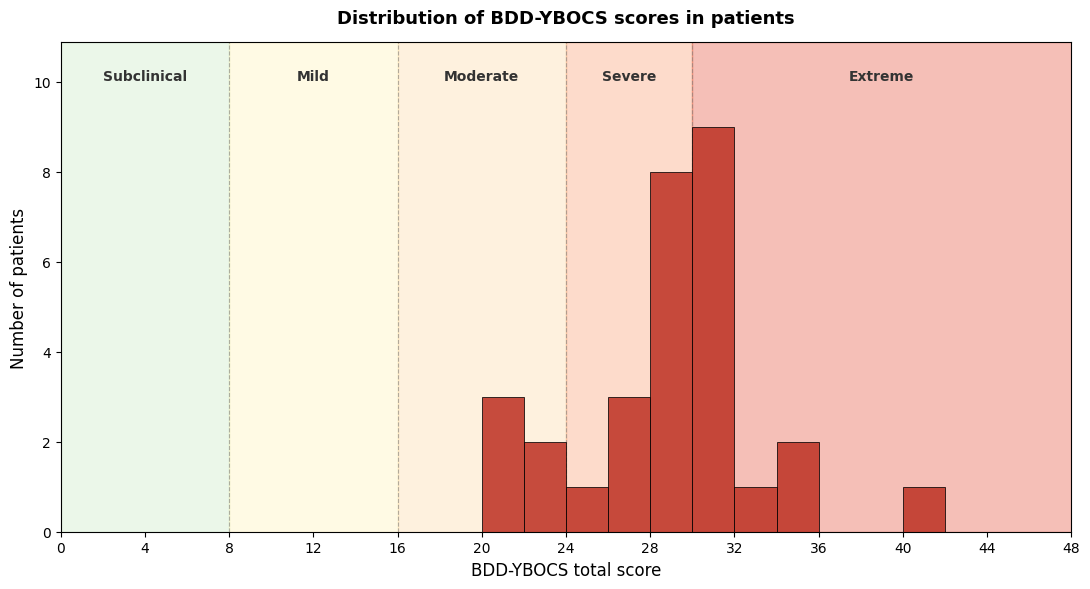

In [11]:
"""
Histogram of BDD-YBOCS scores from Cleaned_Demographics.xlsx (patients only),
with severity ranges shaded.

Severity bands:
    Subclinical  : 0-7    (Y-BOCS convention, commonly adapted for BDD)
    Mild         : 8-15   (Y-BOCS convention, commonly adapted for BDD)
    Moderate     : 16-23  (below empirical cutoff for moderate BDD)
    Severe       : 24-29  (Cervin et al. 2025 empirical moderate cutoff;
                           also standard clinical-trial inclusion floor)
    Extreme      : 30-48  (Cervin et al. 2025 severe + extreme combined)

BDD-YBOCS range: 0-48 (12 items x 0-4).
Empirical cutoffs from:
  Cervin et al. (2025), J. Psychiatric Research.
  "BDD-YBOCS scores 24-29 moderate, 30-36 severe, 37-48 extreme."
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------------------------------------------------------------------
# 1. Load the cleaned file and keep only patients
# ---------------------------------------------------------------------------
INPUT_PATH = "/Volumes/drive/AVP-BDD/Cleaned_Demographics.xlsx"
OUTPUT_FIG = "/Volumes/drive/AVP-BDD/BDD_YBOCS_histogram.png"

df = pd.read_excel(INPUT_PATH)

if 'BDDYBOCS' not in df.columns:
    raise KeyError(
        f"Column 'BDDYBOCS' not found. Available columns: {df.columns.tolist()}"
    )

patients = df[df['group'] == 'Patients'].copy()
scores = patients['BDDYBOCS'].dropna()
print(f"Patient BDD-YBOCS scores: n={len(scores)}, "
      f"mean={scores.mean():.2f}, SD={scores.std(ddof=1):.2f}, "
      f"range={int(scores.min())}-{int(scores.max())}")

# ---------------------------------------------------------------------------
# 2. Define severity bands and colors
# ---------------------------------------------------------------------------
bands = [
    ('Subclinical', 0,  8,  '#c6e9c0'),   # light green
    ('Mild',        8,  16, '#fff2b2'),   # light yellow
    ('Moderate',    16, 24, '#fdd8a1'),   # light orange
    ('Severe',      24, 30, '#fb9a6b'),   # darker orange
    ('Extreme',     30, 49, '#e34a33'),   # red
]

# ---------------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

# --- Shaded severity bands in the background ---
for label, lo, hi, color in bands:
    ax.axvspan(lo, hi, alpha=0.35, color=color, zorder=0)

# --- Histogram (patients only) ---
bins = np.arange(0, 50, 2)   # 2-point bins across full 0-48 range
ax.hist(scores, bins=bins, color='#c0392b', edgecolor='black',
        linewidth=0.6, alpha=0.9, label=f'Patients (n={len(scores)})',
        zorder=2)

# --- Severity band labels above the plot ---
ymax = ax.get_ylim()[1]
ax.set_ylim(0, ymax * 1.15)
for label, lo, hi, color in bands:
    ax.text((lo + min(hi, 48)) / 2, ymax * 1.07, label,
            ha='center', va='center', fontsize=10, fontweight='bold',
            color='#333333')

# --- Vertical lines at the cutoffs ---
for _, lo, _, _ in bands[1:]:  # skip 0
    ax.axvline(lo, color='gray', linestyle='--', linewidth=0.8,
               alpha=0.6, zorder=1)

# --- Axis cosmetics ---
ax.set_xlabel('BDD-YBOCS total score', fontsize=12)
ax.set_ylabel('Number of patients', fontsize=12)
ax.set_title('Distribution of BDD-YBOCS scores in patients', fontsize=13,
             fontweight='bold', pad=14)
ax.set_xlim(0, 48)
ax.set_xticks(range(0, 49, 4))

# --- Legend: group + severity bands ---
band_patches = [Patch(facecolor=c, alpha=0.5, label=f'{lbl} ({lo}-{min(hi-1,48)})')
                for lbl, lo, hi, c in bands]
group_handles, _ = ax.get_legend_handles_labels()
# ax.legend(handles=group_handles + band_patches,
#           loc='upper right', fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=200, bbox_inches='tight')
print(f"Histogram saved to: {OUTPUT_FIG}")

# ---------------------------------------------------------------------------
# 4. Print counts per severity band
# ---------------------------------------------------------------------------
def band_of(score):
    if pd.isna(score):
        return np.nan
    for label, lo, hi, _ in bands:
        if lo <= score < hi:
            return label
    return np.nan

patients['severity_band'] = patients['BDDYBOCS'].apply(band_of)
order = [b[0] for b in bands]
counts = (patients['severity_band']
          .value_counts()
          .reindex(order, fill_value=0)
          .to_frame('n'))
counts['%'] = (counts['n'] / counts['n'].sum() * 100).round(1)
print("\nPatients by severity band:")
print(counts)

plt.show()

Patient BABS scores: n=30, mean=14.97, SD=4.82, range=4-22
Histogram saved to: /Volumes/drive/AVP-BDD/BABS_histogram.png

Patients by insight category:
                    n     %
insight_band               
Excellent           0   0.0
Good                4  13.3
Fair                2   6.7
Poor               14  46.7
Absent/Delusional  10  33.3


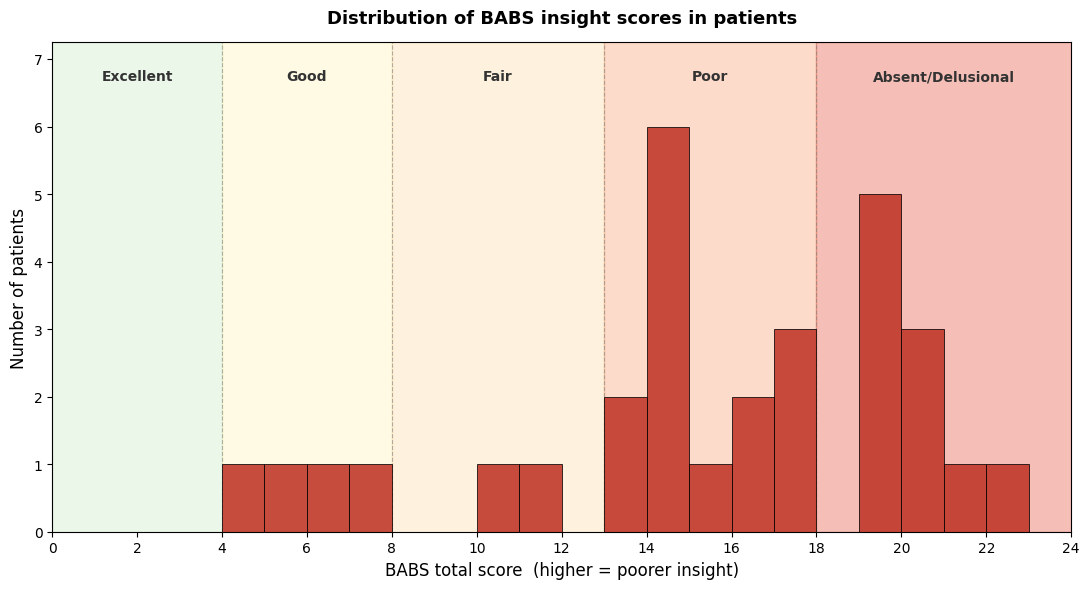

In [12]:
"""
Histogram of BABS (Brown Assessment of Beliefs Scale) scores from
Cleaned_Demographics.xlsx (patients only), with insight categories shaded.

Insight categories (Eisen et al., 1998; Phillips et al., 2013):
    Excellent insight : 0-3
    Good insight      : 4-7
    Fair insight      : 8-12
    Poor insight      : 13-17
    Absent/Delusional : >=18  (formally also requires item 1 = 4;
                               with total score alone this is a conservative flag)

BABS range: 0-24 (items 1-6 summed; item 7 is excluded from the total).
Higher scores = POORER insight (opposite direction from symptom severity scales).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------------------------------------------------------------------
# 1. Load the cleaned file and keep only patients
# ---------------------------------------------------------------------------
INPUT_PATH = "/Volumes/drive/AVP-BDD/Cleaned_Demographics.xlsx"
OUTPUT_FIG = "/Volumes/drive/AVP-BDD/BABS_histogram.png"

df = pd.read_excel(INPUT_PATH)

if 'BABS' not in df.columns:
    raise KeyError(
        f"Column 'BABS' not found. Available columns: {df.columns.tolist()}"
    )

patients = df[df['group'] == 'Patients'].copy()
scores = patients['BABS'].dropna()
print(f"Patient BABS scores: n={len(scores)}, "
      f"mean={scores.mean():.2f}, SD={scores.std(ddof=1):.2f}, "
      f"range={int(scores.min())}-{int(scores.max())}")

# ---------------------------------------------------------------------------
# 2. Insight categories
#    Color gradient: green (good insight) -> red (absent/delusional)
# ---------------------------------------------------------------------------
bands = [
    ('Excellent',         0,  4,  '#c6e9c0'),   # green
    ('Good',              4,  8,  '#fff2b2'),   # yellow
    ('Fair',              8,  13, '#fdd8a1'),   # light orange
    ('Poor',              13, 18, '#fb9a6b'),   # darker orange
    ('Absent/Delusional', 18, 25, '#e34a33'),   # red
]

# ---------------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

# --- Shaded insight bands in the background ---
for label, lo, hi, color in bands:
    ax.axvspan(lo, hi, alpha=0.35, color=color, zorder=0)

# --- Histogram (patients only) --
# Use 1-point bins since BABS total range is only 0-24
bins = np.arange(0, 26, 1)
ax.hist(scores, bins=bins, color='#c0392b', edgecolor='black',
        linewidth=0.6, alpha=0.9, label=f'Patients (n={len(scores)})',
        zorder=2)

# --- Category labels above the plot ---
ymax = ax.get_ylim()[1]
ax.set_ylim(0, ymax * 1.15)
for label, lo, hi, _ in bands:
    ax.text((lo + min(hi, 24)) / 2, ymax * 1.07, label,
            ha='center', va='center', fontsize=10, fontweight='bold',
            color='#333333')

# --- Vertical lines at the cutoffs ---
for _, lo, _, _ in bands[1:]:
    ax.axvline(lo, color='gray', linestyle='--', linewidth=0.8,
               alpha=0.6, zorder=1)

# --- Axis cosmetics ---
ax.set_xlabel('BABS total score  (higher = poorer insight)', fontsize=12)
ax.set_ylabel('Number of patients', fontsize=12)
ax.set_title('Distribution of BABS insight scores in patients', fontsize=13,
             fontweight='bold', pad=14)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))

# --- Legend: group + insight bands ---
band_patches = [Patch(facecolor=c, alpha=0.5,
                      label=f'{lbl} ({lo}-{min(hi-1,24)})')
                for lbl, lo, hi, c in bands]
group_handles, _ = ax.get_legend_handles_labels()
# ax.legend(handles=group_handles + band_patches,
#           loc='upper right', fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=200, bbox_inches='tight')
print(f"Histogram saved to: {OUTPUT_FIG}")

# ---------------------------------------------------------------------------
# 4. Print counts per insight category
# ---------------------------------------------------------------------------
def band_of(score):
    if pd.isna(score):
        return np.nan
    for label, lo, hi, _ in bands:
        if lo <= score < hi:
            return label
    return np.nan

patients['insight_band'] = patients['BABS'].apply(band_of)
order = [b[0] for b in bands]
counts = (patients['insight_band']
          .value_counts()
          .reindex(order, fill_value=0)
          .to_frame('n'))
counts['%'] = (counts['n'] / counts['n'].sum() * 100).round(1)
print("\nPatients by insight category:")
print(counts)

plt.show()